# Model Training Results: Pairwise Amino Acid Classification

This notebook analyzes model training results from pairwise amino acid comparisons.
We compare different model architectures and evaluate the impact of dwell time features.

**Data source**: `summary.tsv` - generated from `uv run python workflow/scripts/test_summarize_metrics.py`

In [1]:
import json
import warnings

import pandas as pd
import polars as pl
from great_tables import GT
from plotnine import *

warnings.filterwarnings("ignore")

# Set plot aesthetics
theme_set(theme_minimal() + theme(figure_size=(12, 6)))

## Load Data

In [2]:
# Load the pairwise metrics summary data
data_path = "../summary.tsv"

df_raw = pl.read_csv(data_path, separator="\t")

print(f"Total rows: {len(df_raw)}")
print(f"Total pairs: {df_raw['pair'].n_unique()}")
print(f"Models: {df_raw['model'].unique().to_list()}")
print(f"\nColumns: {df_raw.columns}")

Total rows: 1140
Total pairs: 190
Models: ['TCNDwell', 'ConvOnly', 'ConvLSTMBase', 'ConvLSTMDwell', 'TransformerDwell', 'ResNetDwell']

Columns: ['pair', 'model', 'sample', 'train_acc', 'train_loss', 'val_acc', 'val_auc', 'val_loss']


In [3]:
# Show first few rows of raw data
df_raw.head(3)

pair,model,sample,train_acc,train_loss,val_acc,val_auc,val_loss
str,str,str,str,str,str,str,str
"""Ala_Arg""","""ConvLSTMBase""","""ConvLSTMBase""","""[0.8395061728395061, 0.8395061…","""[0.5769900232553482, 0.4556518…","""[0.8076923076923077, 0.8076923…","""[0.5063988095238094, 0.5183035…","""[0.4341594725847244, 0.4347046…"
"""Ala_Arg""","""ConvLSTMDwell""","""ConvLSTMDwell""","""[0.7263374485596708, 0.8395061…","""[0.6087692677974701, 0.4558739…","""[0.8076923076923077, 0.8076923…","""[0.47261904761904766, 0.652529…","""[0.43693938106298447, 0.434228…"
"""Ala_Arg""","""ConvOnly""","""ConvOnly""","""[0.6327160493827161, 0.7983539…","""[0.6763685047626495, 0.4865723…","""[0.8076923076923077, 0.8076923…","""[0.7461309523809524, 0.8244047…","""[0.5451491177082062, 0.4210346…"


In [4]:
import json


# Function to safely parse array strings and extract final/best values
def parse_array_column(value):
    """Parse stringified arrays and return list of floats."""
    if pd.isna(value):
        return []
    try:
        # Try to parse as JSON array
        if isinstance(value, str):
            return json.loads(value.replace("nan", "null"))
        return value
    except:
        return []


def get_final_value(value):
    """Get the final value from an array."""
    arr = parse_array_column(value)
    return arr[-1] if arr else float("nan")


def get_best_value(value, higher_better=True):
    """Get the best value from an array."""
    arr = parse_array_column(value)
    if not arr:
        return float("nan")
    return max(arr) if higher_better else min(arr)


# Convert to pandas for easier processing
df_raw_pd = df_raw.to_pandas()

# Filter out rows where model is None/NaN
df_raw_pd = df_raw_pd[df_raw_pd["model"].notna()].copy()

# Create new dataframe with only the columns we need
# Start with metadata columns
df = pd.DataFrame({
    "pair": df_raw_pd["pair"],
    "model": df_raw_pd["model"],
    "architecture": df_raw_pd["model"].astype(str),  # Explicitly convert to string
})

# Extract metrics (using best validation values)
df["accuracy_mean"] = df_raw_pd["val_acc"].apply(get_best_value)
df["auroc_mean"] = df_raw_pd["val_auc"].apply(get_best_value)

# For metrics not in the data, check if they exist
if "val_f1" in df_raw_pd.columns:
    df["f1_mean"] = df_raw_pd["val_f1"].apply(get_best_value)
else:
    # Calculate F1 from accuracy as approximation if not available
    df["f1_mean"] = df["accuracy_mean"]

if "val_auprc" in df_raw_pd.columns:
    df["auprc_mean"] = df_raw_pd["val_auprc"].apply(get_best_value)
else:
    # Use AUROC as proxy if AUPRC not available
    df["auprc_mean"] = df["auroc_mean"]

# Extract training metrics
df["train_accuracy_final"] = df_raw_pd["train_acc"].apply(get_final_value)
df["train_loss_final"] = df_raw_pd["train_loss"].apply(lambda x: get_best_value(x, False))
df["val_loss_final"] = df_raw_pd["val_loss"].apply(lambda x: get_best_value(x, False))

print("\nProcessed data summary:")
print(f"Total rows: {len(df)}")
print(f"Unique architectures: {df['architecture'].unique()}")
print(f"\nSample of processed metrics:")
print(df[["pair", "architecture", "accuracy_mean", "auroc_mean", "f1_mean"]].head(10))


Processed data summary:
Total rows: 1140
Unique architectures: ['ConvLSTMBase' 'ConvLSTMDwell' 'ConvOnly' 'ResNetDwell' 'TCNDwell' 'TransformerDwell']

Sample of processed metrics:
      pair      architecture  accuracy_mean  auroc_mean   f1_mean
0  Ala_Arg      ConvLSTMBase       0.807692    0.679613  0.807692
1  Ala_Arg     ConvLSTMDwell       0.807692    0.652530  0.807692
2  Ala_Arg          ConvOnly       0.927885    0.933929  0.927885
3  Ala_Arg       ResNetDwell       0.927885    0.933333  0.927885
4  Ala_Arg          TCNDwell       0.927885    0.905804  0.927885
5  Ala_Arg  TransformerDwell       0.807692    0.546205  0.807692
6  Ala_Asn      ConvLSTMBase       0.894180    0.773669  0.894180
7  Ala_Asn     ConvLSTMDwell       0.894180    0.685207  0.894180
8  Ala_Asn          ConvOnly       0.904762    0.891124  0.904762
9  Ala_Asn       ResNetDwell       0.899471    0.810651  0.899471


In [5]:
# Show first few rows of processed data
df[["pair", "architecture", "accuracy_mean", "auroc_mean", "f1_mean", "auprc_mean", "train_accuracy_final"]].head(10)

,pair,architecture,accuracy_mean,auroc_mean,f1_mean,auprc_mean,train_accuracy_final
0,Ala_Arg,ConvLSTMBase,0.807692,0.679613,0.807692,0.679613,0.839506
1,Ala_Arg,ConvLSTMDwell,0.807692,0.652530,0.807692,0.652530,0.839506
2,Ala_Arg,ConvOnly,0.927885,0.933929,0.927885,0.933929,0.968107
3,Ala_Arg,ResNetDwell,0.927885,0.933333,0.927885,0.933333,0.957819
4,Ala_Arg,TCNDwell,0.927885,0.905804,0.927885,0.905804,0.925926
5,Ala_Arg,TransformerDwell,0.807692,0.546205,0.807692,0.546205,0.839506
6,Ala_Asn,ConvLSTMBase,0.894180,0.773669,0.894180,0.773669,0.802260
7,Ala_Asn,ConvLSTMDwell,0.894180,0.685207,0.894180,0.685207,0.802260
8,Ala_Asn,ConvOnly,0.904762,0.891124,0.904762,0.891124,0.916384
9,Ala_Asn,ResNetDwell,0.899471,0.810651,0.899471,0.810651,0.899435


## Process Training History

The data contains training history arrays. We'll extract summary statistics (final values, means, etc.) for analysis.

In [6]:
# Overall performance by architecture
summary = (
    df.groupby("architecture")
    .agg(
        {
            "accuracy_mean": ["mean", "std"],
            "f1_mean": ["mean", "std"],
            "auroc_mean": ["mean", "std"],
        }
    )
    .reset_index()
)

# Flatten column names
summary.columns = [
    "architecture",
    "avg_accuracy",
    "std_accuracy",
    "avg_f1",
    "std_f1",
    "avg_auroc",
    "std_auroc",
]
summary["n_pairs"] = df.groupby("architecture").size().values
summary = summary.sort_values("avg_f1", ascending=False)

print("\nOverall Performance by Architecture (averaged across all pairs):")
print(summary)


Overall Performance by Architecture (averaged across all pairs):
       architecture  avg_accuracy  std_accuracy    avg_f1    std_f1  avg_auroc  std_auroc  n_pairs
4          TCNDwell      0.898650      0.075521  0.898650  0.075521   0.899355   0.078148      190
2          ConvOnly      0.898640      0.076287  0.898640  0.076287   0.900400   0.076277      190
3       ResNetDwell      0.896427      0.077146  0.896427  0.077146   0.894948   0.080373      190
0      ConvLSTMBase      0.890561      0.080547  0.890561  0.080547   0.870961   0.109797      190
1     ConvLSTMDwell      0.887478      0.082702  0.887478  0.082702   0.863302   0.115474      190
5  TransformerDwell      0.775384      0.145628  0.775384  0.145628   0.584126   0.066769      190


In [7]:
# Identify best and worst performing pairs
best_pairs = (
    df.sort_values("f1_mean", ascending=False)[
        ["pair", "architecture", "f1_mean", "accuracy_mean"]
    ].head(10)
)
worst_pairs = df.sort_values("f1_mean")[["pair", "architecture", "f1_mean", "accuracy_mean"]].head(
    10
)

print("\nTop 10 Best Performing Pairs:")
print(best_pairs)
print("\nTop 10 Most Challenging Pairs:")
print(worst_pairs)


Top 10 Best Performing Pairs:
       pair      architecture   f1_mean  accuracy_mean
34  Ala_Glu          TCNDwell  0.992966       0.992966
31  Ala_Glu     ConvLSTMDwell  0.992139       0.992139
33  Ala_Glu       ResNetDwell  0.991725       0.991725
32  Ala_Glu          ConvOnly  0.991725       0.991725
84  Ala_Ser      ConvLSTMBase  0.991406       0.991406
87  Ala_Ser       ResNetDwell  0.991406       0.991406
88  Ala_Ser          TCNDwell  0.991406       0.991406
86  Ala_Ser          ConvOnly  0.991406       0.991406
85  Ala_Ser     ConvLSTMDwell  0.991406       0.991406
89  Ala_Ser  TransformerDwell  0.991406       0.991406

Top 10 Most Challenging Pairs:
         pair      architecture   f1_mean  accuracy_mean
995   Met_Thr  TransformerDwell  0.500266       0.500266
173   Arg_Lys  TransformerDwell  0.506494       0.506494
557   Gln_Phe  TransformerDwell  0.509920       0.509920
383   Asp_Phe  TransformerDwell  0.515876       0.515876
119   Arg_Asn  TransformerDwell  0.518405      

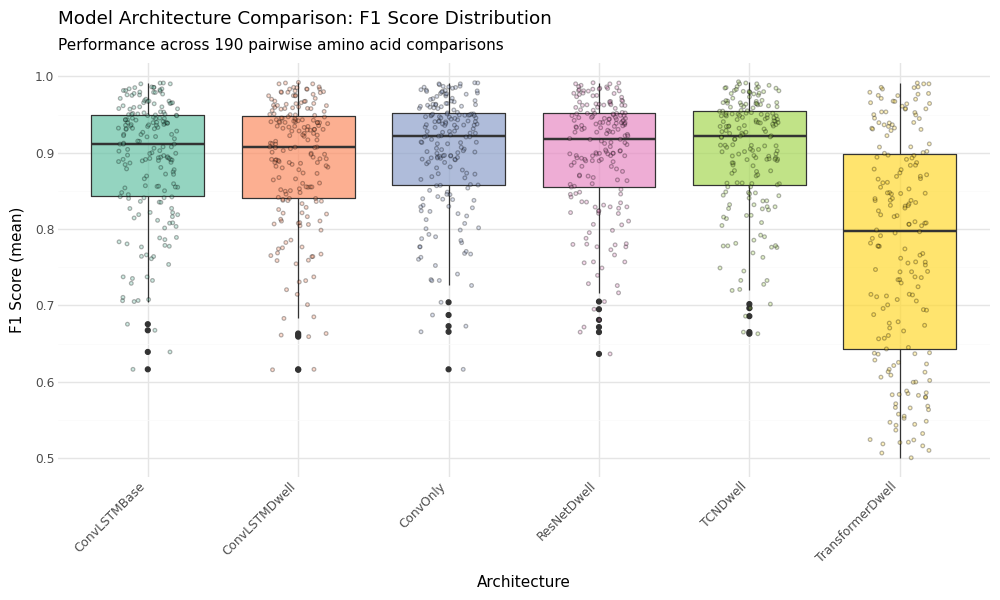

In [8]:
# Use df directly (it's already pandas)
df_pd = df

# Box plot of F1 scores by architecture
p1 = (
    ggplot(df_pd, aes(x="architecture", y="f1_mean", fill="architecture"))
    + geom_boxplot(alpha=0.7)
    + geom_jitter(width=0.2, height=0, alpha=0.3, size=1)
    + labs(
        title="Model Architecture Comparison: F1 Score Distribution",
        subtitle=f"Performance across {df['pair'].nunique()} pairwise amino acid comparisons",
        x="Architecture",
        y="F1 Score (mean)",
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1), legend_position="none", figure_size=(10, 6)
    )
    + scale_fill_brewer(type="qual", palette="Set2")
)

p1

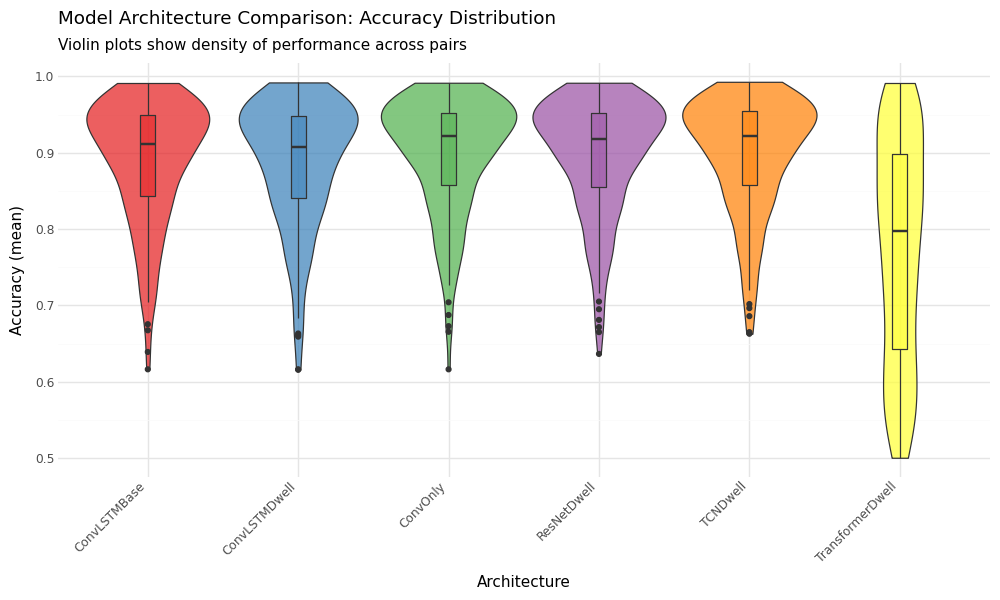

In [9]:
# Violin plot showing distribution density
p2 = (
    ggplot(df_pd, aes(x="architecture", y="accuracy_mean", fill="architecture"))
    + geom_violin(alpha=0.7)
    + geom_boxplot(width=0.1, alpha=0.5)
    + labs(
        title="Model Architecture Comparison: Accuracy Distribution",
        subtitle="Violin plots show density of performance across pairs",
        x="Architecture",
        y="Accuracy (mean)",
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1), legend_position="none", figure_size=(10, 6)
    )
    + scale_fill_brewer(type="qual", palette="Set1")
)

p2

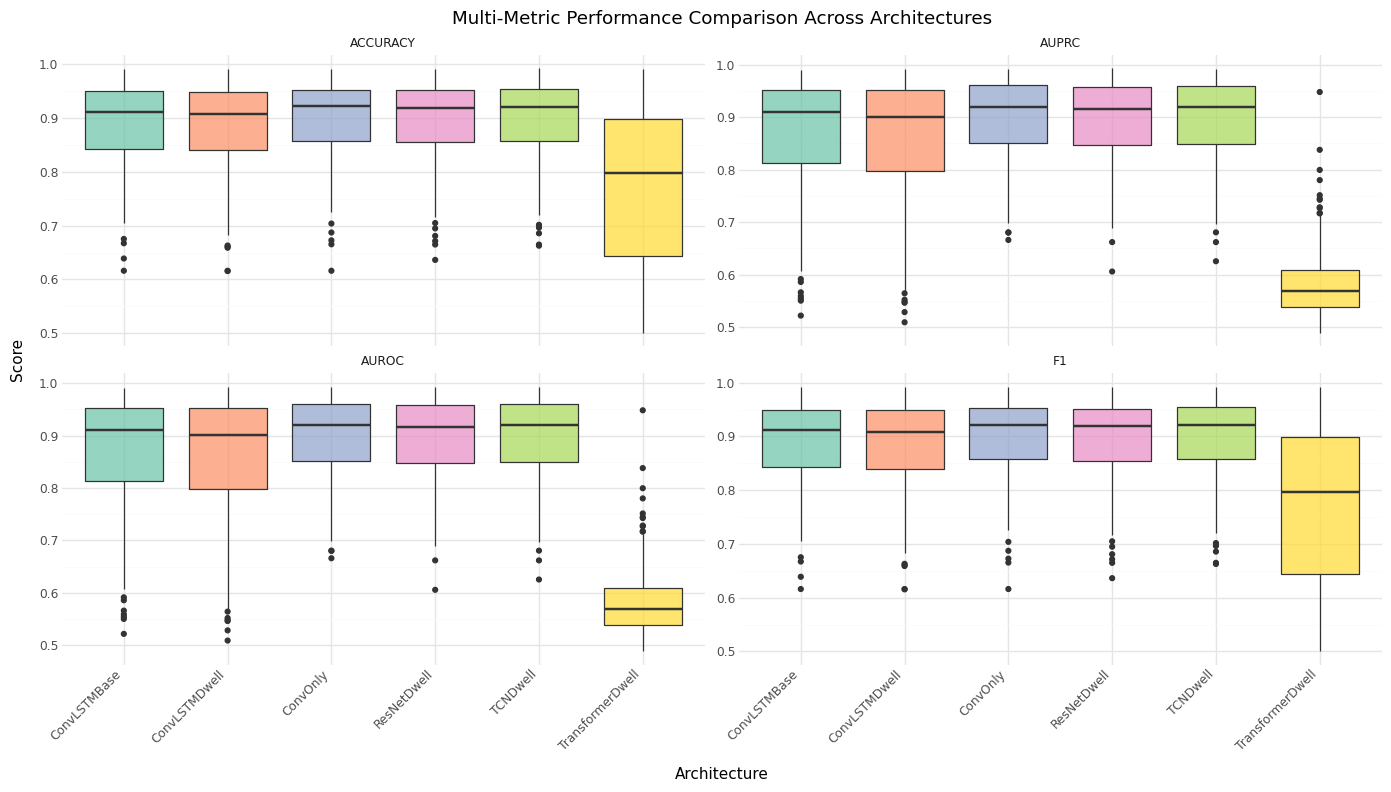

In [10]:
# Multi-metric comparison
metrics_long = df_pd.melt(
    id_vars=["pair", "architecture"],
    value_vars=["accuracy_mean", "f1_mean", "auroc_mean", "auprc_mean"],
    var_name="metric",
    value_name="score",
)

# Clean up metric names
metrics_long["metric"] = metrics_long["metric"].str.replace("_mean", "").str.upper()

p3 = (
    ggplot(metrics_long, aes(x="architecture", y="score", fill="architecture"))
    + geom_boxplot(alpha=0.7)
    + facet_wrap("~metric", scales="free_y")
    + labs(
        title="Multi-Metric Performance Comparison Across Architectures",
        x="Architecture",
        y="Score",
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1), legend_position="none", figure_size=(14, 8)
    )
    + scale_fill_brewer(type="qual", palette="Set2")
)

p3

In [11]:
# Identify dwell vs non-dwell architectures
architectures = [a for a in df_pd["architecture"].unique() if a is not None]
print(f"Available architectures: {architectures}")

# Try to identify dwell-enabled vs baseline models
dwell_models = [arch for arch in architectures if "dwell" in arch.lower()]
base_models = [arch for arch in architectures if "base" in arch.lower()]

print(f"\nDwell-enabled models: {dwell_models}")
print(f"Baseline models: {base_models}")

Available architectures: ['ConvLSTMBase', 'ConvLSTMDwell', 'ConvOnly', 'ResNetDwell', 'TCNDwell', 'TransformerDwell']

Dwell-enabled models: ['ConvLSTMDwell', 'ResNetDwell', 'TCNDwell', 'TransformerDwell']
Baseline models: ['ConvLSTMBase']


In [12]:
# If we have both dwell and base models, create direct comparison
if dwell_models and base_models:
    # Create a subset for dwell comparison
    dwell_comparison = df_pd[df_pd["architecture"].isin(dwell_models + base_models)].copy()

    # Categorize as dwell or baseline
    dwell_comparison["feature_type"] = dwell_comparison["architecture"].apply(
        lambda x: "With Dwell Features" if "dwell" in x.lower() else "Baseline (No Dwell)"
    )

    # Calculate improvement for each pair
    if len(dwell_models) == 1 and len(base_models) == 1:
        dwell_arch = dwell_models[0]
        base_arch = base_models[0]

        dwell_df = df[df["architecture"] == dwell_arch][
            ["pair", "f1_mean", "accuracy_mean"]
        ].rename(columns={"f1_mean": "f1_dwell", "accuracy_mean": "acc_dwell"})
        base_df = df[df["architecture"] == base_arch][
            ["pair", "f1_mean", "accuracy_mean"]
        ].rename(columns={"f1_mean": "f1_base", "accuracy_mean": "acc_base"})

        improvement_df = dwell_df.merge(base_df, on="pair")
        improvement_df["f1_improvement"] = improvement_df["f1_dwell"] - improvement_df["f1_base"]
        improvement_df["acc_improvement"] = improvement_df["acc_dwell"] - improvement_df["acc_base"]

        print(f"\nDwell Time Feature Impact ({dwell_arch} vs {base_arch}):")
        print(
            f"Mean F1 improvement: {improvement_df['f1_improvement'].mean():.4f} ± {improvement_df['f1_improvement'].std():.4f}"
        )
        print(
            f"Mean Accuracy improvement: {improvement_df['acc_improvement'].mean():.4f} ± {improvement_df['acc_improvement'].std():.4f}"
        )
        print(
            f"Pairs where dwell helps (F1): {(improvement_df['f1_improvement'] > 0).sum()} / {len(improvement_df)}"
        )
        print(
            f"Pairs where dwell helps (Acc): {(improvement_df['acc_improvement'] > 0).sum()} / {len(improvement_df)}"
        )
else:
    print("Note: Could not identify both dwell and baseline models for direct comparison.")
    dwell_comparison = df_pd.copy()
    dwell_comparison["feature_type"] = dwell_comparison["architecture"]

## Visualization 2: Dwell Time Feature Impact

Compare models with and without dwell time features to quantify their impact.

In [13]:
# Side-by-side comparison of dwell vs baseline
if dwell_models and base_models:
    p4 = (
        ggplot(dwell_comparison, aes(x="feature_type", y="f1_mean", fill="feature_type"))
        + geom_boxplot(alpha=0.7)
        + geom_jitter(width=0.2, height=0, alpha=0.2, size=1)
        + labs(
            title="Impact of Dwell Time Features on Model Performance",
            subtitle="F1 Score distribution with and without dwell time features",
            x="Model Type",
            y="F1 Score (mean)",
        )
        + theme(legend_position="none", figure_size=(10, 6))
        + scale_fill_manual(values=["#E74C3C", "#3498DB"])
    )

    p4

In [14]:
# Histogram of improvement from dwell features
if dwell_models and base_models and len(dwell_models) == 1 and len(base_models) == 1:
    p5 = (
        ggplot(improvement_df, aes(x="f1_improvement"))
        + geom_histogram(bins=30, fill="#2ECC71", alpha=0.7, color="black")
        + geom_vline(xintercept=0, linetype="dashed", color="red", size=1)
        + labs(
            title="Distribution of F1 Score Improvement from Dwell Time Features",
            subtitle=f"Comparing {dwell_arch} vs {base_arch} across {len(improvement_df)} pairs",
            x="F1 Score Improvement (Dwell - Baseline)",
            y="Count",
        )
        + theme(figure_size=(10, 6))
    )

    p5

In [15]:
# Scatter plot: baseline vs dwell performance
if dwell_models and base_models and len(dwell_models) == 1 and len(base_models) == 1:
    p6 = (
        ggplot(improvement_df, aes(x="f1_base", y="f1_dwell"))
        + geom_point(alpha=0.6, size=2, color="#9B59B6")
        + geom_abline(intercept=0, slope=1, linetype="dashed", color="red", size=0.8)
        + labs(
            title="Baseline vs Dwell-Enhanced Model Performance",
            subtitle="Points above red line indicate dwell features improve performance",
            x=f"F1 Score - {base_arch}",
            y=f"F1 Score - {dwell_arch}",
        )
        + theme(figure_size=(10, 10))
        + coord_fixed()
    )

    p6

In [16]:
# Average performance per pair across all architectures
pair_performance = (
    df.groupby("pair")
    .agg({"f1_mean": "mean", "accuracy_mean": "mean", "auroc_mean": "mean"})
    .rename(columns={"f1_mean": "avg_f1", "accuracy_mean": "avg_accuracy", "auroc_mean": "avg_auroc"})
    .sort_values("avg_f1", ascending=False)
    .reset_index()
)

# Get top and bottom 15
top_pairs = pair_performance.head(15)
bottom_pairs = pair_performance.tail(15)

print("Top 15 Easiest Pairs to Classify:")
print(top_pairs)
print("\nTop 15 Hardest Pairs to Classify:")
print(bottom_pairs)

Top 15 Easiest Pairs to Classify:
       pair    avg_f1  avg_accuracy  avg_auroc
0   Ala_Ser  0.991406      0.991406   0.803136
1   Ala_Glu  0.990553      0.990553   0.883082
2   Ala_Val  0.990303      0.990303   0.775140
3   Ala_Pro  0.990271      0.990271   0.670540
4   Ala_Leu  0.986282      0.986282   0.798027
5   Cys_Pro  0.986257      0.986257   0.768627
6   Cys_Ser  0.985363      0.985363   0.840639
7   Ala_Asp  0.984990      0.984990   0.870226
8   Ala_Gln  0.981602      0.981602   0.878929
9   Lys_Ser  0.980346      0.980346   0.918895
10  Ala_Tyr  0.979987      0.979987   0.757929
11  Cys_Val  0.979535      0.979535   0.821010
12  Arg_Ser  0.978396      0.978396   0.908274
13  Ala_Phe  0.976407      0.976407   0.754839
14  Glu_Lys  0.973721      0.973721   0.918019

Top 15 Hardest Pairs to Classify:
        pair    avg_f1  avg_accuracy  avg_auroc
175  Phe_Thr  0.738084      0.738084   0.805016
176  His_Phe  0.731836      0.731836   0.797934
177  Phe_Trp  0.726612      0.72661

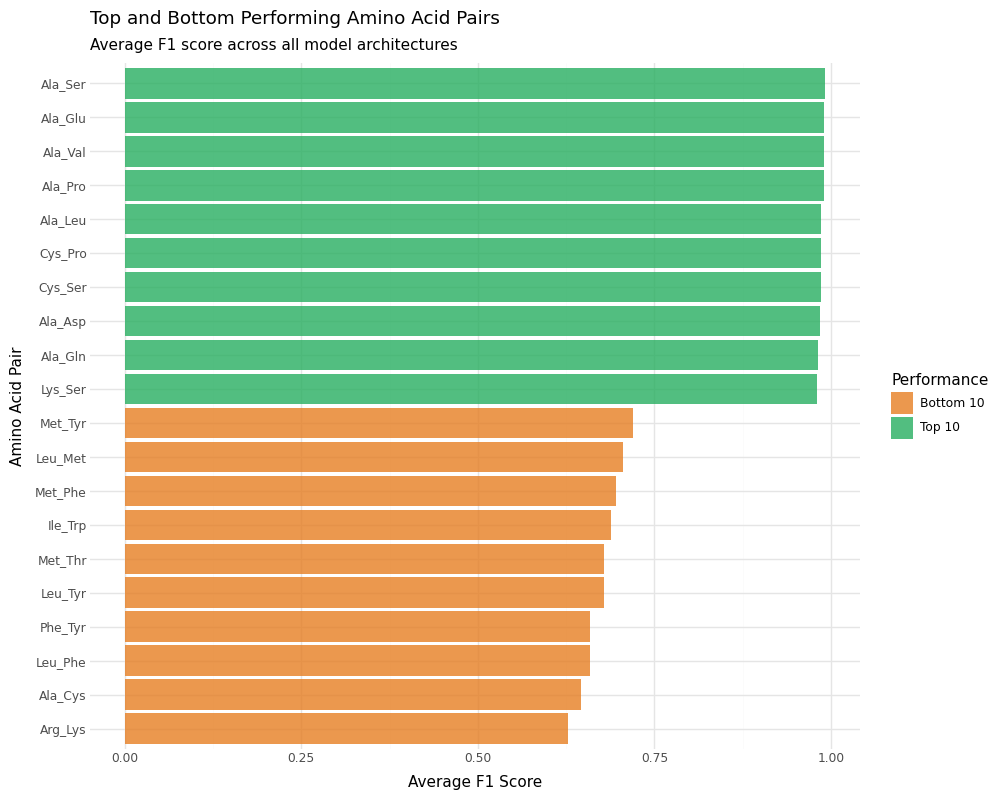

In [17]:
# Bar plot of top and bottom pairs
extreme_pairs = pd.concat([top_pairs.head(10), bottom_pairs.tail(10)])
extreme_pairs["category"] = ["Top 10"] * 10 + ["Bottom 10"] * 10

p7 = (
    ggplot(extreme_pairs, aes(x="reorder(pair, avg_f1)", y="avg_f1", fill="category"))
    + geom_col(alpha=0.8)
    + coord_flip()
    + labs(
        title="Top and Bottom Performing Amino Acid Pairs",
        subtitle="Average F1 score across all model architectures",
        x="Amino Acid Pair",
        y="Average F1 Score",
        fill="Performance",
    )
    + theme(figure_size=(10, 8))
    + scale_fill_manual(values=["#E67E22", "#27AE60"])
)

p7

In [18]:
# Calculate coefficient of variation (std/mean) for each pair across architectures
pair_variability = (
    df.groupby("pair")
    .agg({"f1_mean": ["mean", "std"]})
    .reset_index()
)
pair_variability.columns = ["pair", "avg_f1", "std_f1"]
pair_variability["cv_f1"] = pair_variability["std_f1"] / pair_variability["avg_f1"]
pair_variability = pair_variability.sort_values("cv_f1", ascending=False)

print("Top 15 pairs with HIGHEST variability across architectures:")
print(pair_variability.head(15))

print("\nTop 15 pairs with LOWEST variability (most consistent):")
print(pair_variability.tail(15))

Top 15 pairs with HIGHEST variability across architectures:
        pair    avg_f1    std_f1     cv_f1
87   Gln_His  0.865170  0.168782  0.195086
63   Asp_Phe  0.854639  0.165992  0.194225
92   Gln_Phe  0.827494  0.155588  0.188023
58   Asp_His  0.873568  0.159445  0.182521
111  Glu_Val  0.895213  0.162646  0.181684
19   Arg_Asn  0.816462  0.147130  0.180204
68   Asp_Tyr  0.850663  0.150832  0.177312
102  Glu_Leu  0.869712  0.153033  0.175958
179  Pro_Val  0.792012  0.131300  0.165780
115  Gly_Lys  0.905295  0.149816  0.165488
127  His_Met  0.789904  0.130530  0.165248
24   Arg_Gly  0.899425  0.143851  0.159937
45   Asn_Lys  0.844262  0.134030  0.158754
110  Glu_Tyr  0.883075  0.134509  0.152319
97   Gln_Tyr  0.790503  0.119522  0.151197

Top 15 pairs with LOWEST variability (most consistent):
        pair    avg_f1    std_f1     cv_f1
49   Asn_Ser  0.972222  0.001150  0.001183
119  Gly_Ser  0.950345  0.000967  0.001017
77   Cys_Met  0.932536  0.000801  0.000859
9    Ala_Leu  0.986282 

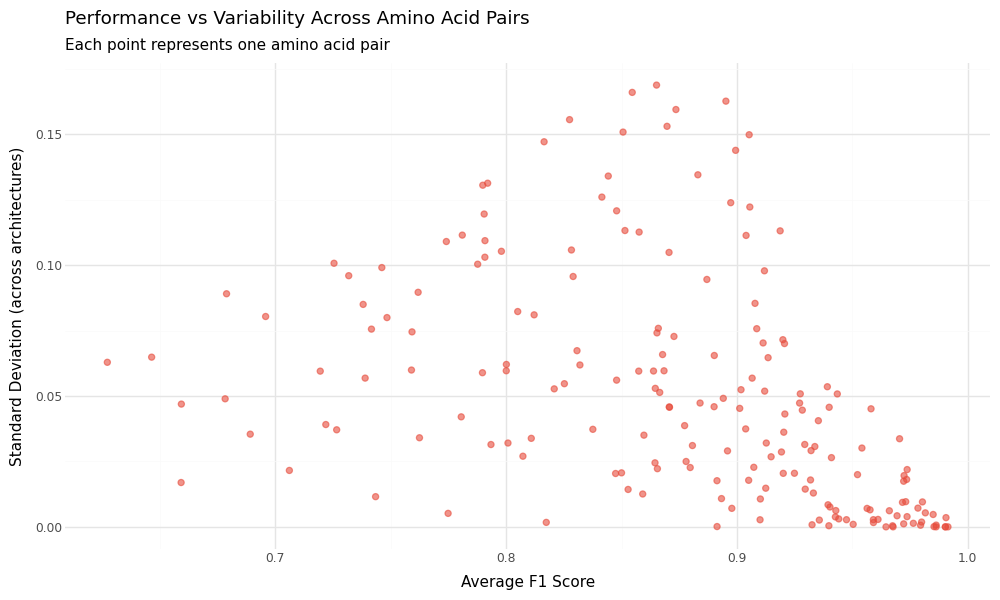

In [19]:
# Scatter plot: mean performance vs variability
pair_var_pd = pair_variability

p8 = (
    ggplot(pair_var_pd, aes(x="avg_f1", y="std_f1"))
    + geom_point(alpha=0.6, size=2, color="#E74C3C")
    + labs(
        title="Performance vs Variability Across Amino Acid Pairs",
        subtitle="Each point represents one amino acid pair",
        x="Average F1 Score",
        y="Standard Deviation (across architectures)",
    )
    + theme(figure_size=(10, 6))
)

p8

In [ ]:
# Create a comprehensive summary
print("=" * 80)
print("COMPREHENSIVE SUMMARY")
print("=" * 80)
print(f"\nTotal amino acid pairs analyzed: {df['pair'].nunique()}")
print(f"Total architectures compared: {df['architecture'].nunique()}")
print(f"Architectures: {', '.join(df['architecture'].unique())}")

print("\n" + "=" * 80)
print("OVERALL ARCHITECTURE RANKINGS")
print("=" * 80)

# Display summary with great_tables
summary_display = summary.copy()
summary_display = summary_display.round(4)

gt_summary = (
    GT(summary_display)
    .tab_header(
        title="Model Architecture Performance Rankings",
        subtitle="Averaged across all 190 pairwise amino acid comparisons"
    )
    .fmt_number(
        columns=["avg_accuracy", "std_accuracy", "avg_f1", "std_f1", "avg_auroc", "std_auroc"],
        decimals=4
    )
    .cols_label(
        architecture="Architecture",
        avg_accuracy="Mean Accuracy",
        std_accuracy="Std Accuracy",
        avg_f1="Mean F1",
        std_f1="Std F1",
        avg_auroc="Mean AUROC",
        std_auroc="Std AUROC",
        n_pairs="N Pairs"
    )
    .data_color(
        columns="avg_f1",
        palette="Greens"
    )
    .tab_options(
        table_font_size="12px",
        heading_title_font_size="16px",
        heading_subtitle_font_size="13px"
    )
)

display(gt_summary)

# Statistical significance of differences
architectures = [a for a in df["architecture"].unique() if a is not None]
if len(architectures) >= 2:
    print("\n" + "=" * 80)
    print("PERFORMANCE DIFFERENCES")
    print("=" * 80)

    # Create a dataframe for pairwise differences
    diff_data = []
    for i, arch1 in enumerate(architectures):
        for arch2 in architectures[i + 1 :]:
            data1 = df[df["architecture"] == arch1]["f1_mean"]
            data2 = df[df["architecture"] == arch2]["f1_mean"]
            diff = data1.mean() - data2.mean()
            diff_data.append({
                "Comparison": f"{arch1} vs {arch2}",
                "F1 Difference": diff
            })

    diff_df = pd.DataFrame(diff_data)

    gt_diff = (
        GT(diff_df)
        .tab_header(
            title="Pairwise Architecture Comparison",
            subtitle="Difference in mean F1 scores (positive = first architecture better)"
        )
        .fmt_number(
            columns="F1 Difference",
            decimals=4,
            force_sign=True
        )
        .data_color(
            columns="F1 Difference",
            palette=["#d73027", "#fee08b", "#d9ef8b", "#1a9850"],
            domain=[-0.02, 0.02]
        )
        .tab_options(
            table_font_size="12px",
            heading_title_font_size="16px",
            heading_subtitle_font_size="13px"
        )
    )

    display(gt_diff)

COMPREHENSIVE SUMMARY

Total amino acid pairs analyzed: 190
Total architectures compared: 6
Architectures: ConvLSTMBase, ConvLSTMDwell, ConvOnly, ResNetDwell, TCNDwell, TransformerDwell

OVERALL ARCHITECTURE RANKINGS


GT(_tbl_data=       architecture  avg_accuracy  std_accuracy  avg_f1  std_f1  avg_auroc  std_auroc  n_pairs
4          TCNDwell        0.8987        0.0755  0.8987  0.0755     0.8994     0.0781      190
2          ConvOnly        0.8986        0.0763  0.8986  0.0763     0.9004     0.0763      190
3       ResNetDwell        0.8964        0.0771  0.8964  0.0771     0.8949     0.0804      190
0      ConvLSTMBase        0.8906        0.0805  0.8906  0.0805     0.8710     0.1098      190
1     ConvLSTMDwell        0.8875        0.0827  0.8875  0.0827     0.8633     0.1155      190
5  TransformerDwell        0.7754        0.1456  0.7754  0.1456     0.5841     0.0668      190, _body=<great_tables._gt_data.Body object at 0x14b9f75951c0>, _boxhead=Boxhead([ColInfo(var='architecture', type=<ColInfoTypeEnum.default: 1>, column_label='Architecture', column_align='left', column_width=None), ColInfo(var='avg_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Mean Accuracy', column_align='right', column_width=None), ColInfo(var='std_accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Std Accuracy', column_align='right', column_width=None), ColInfo(var='avg_f1', type=<ColInfoTypeEnum.default: 1>, column_label='Mean F1', column_align='right', column_width=None), ColInfo(var='std_f1', type=<ColInfoTypeEnum.default: 1>, column_label='Std F1', column_align='right', column_width=None), ColInfo(var='avg_auroc', type=<ColInfoTypeEnum.default: 1>, column_label='Mean AUROC', column_align='right', column_width=None), ColInfo(var='std_auroc', type=<ColInfoTypeEnum.default: 1>, column_label='Std AUROC', column_align='right', column_width=None), ColInfo(var='n_pairs', type=<ColInfoTypeEnum.default: 1>, column_label='N Pairs', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14ba4457dc10>, _spanners=Spanners([]), _heading=Heading(title='Model Architecture Performance Rankings', subtitle='Averaged across all 190 pairwise amino acid comparisons', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x14b9f769e480>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x14b9f769e060>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='avg_f1', rows=[0], mask=None), grpname=None, colname='avg_f1', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#005a24')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[1], mask=None), grpname=None, colname='avg_f1', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#006227')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[2], mask=None), grpname=None, colname='avg_f1', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#00441b')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[3], mask=None), grpname=None, colname='avg_f1', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#004a1e')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[4], mask=None), grpname=None, colname='avg_f1', rownum=4, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#00441b')]), StyleInfo(locname=LocBody(columns='avg_f1', rows=[5], mask=None), grpname=None, colname='avg_f1', rownum=5, co


PERFORMANCE DIFFERENCES


GT(_tbl_data=                           Comparison  F1 Difference
0       ConvLSTMBase vs ConvLSTMDwell       0.003083
1            ConvLSTMBase vs ConvOnly      -0.008079
2         ConvLSTMBase vs ResNetDwell      -0.005866
3            ConvLSTMBase vs TCNDwell      -0.008089
4    ConvLSTMBase vs TransformerDwell       0.115177
5           ConvLSTMDwell vs ConvOnly      -0.011162
6        ConvLSTMDwell vs ResNetDwell      -0.008949
7           ConvLSTMDwell vs TCNDwell      -0.011172
8   ConvLSTMDwell vs TransformerDwell       0.112094
9             ConvOnly vs ResNetDwell       0.002213
10               ConvOnly vs TCNDwell      -0.000010
11       ConvOnly vs TransformerDwell       0.123256
12            ResNetDwell vs TCNDwell      -0.002223
13    ResNetDwell vs TransformerDwell       0.121044
14       TCNDwell vs TransformerDwell       0.123266, _body=<great_tables._gt_data.Body object at 0x14b9f7594110>, _boxhead=Boxhead([ColInfo(var='Comparison', type=<ColInfoTypeEnum.default: 1>, column_label='Comparison', column_align='left', column_width=None), ColInfo(var='F1 Difference', type=<ColInfoTypeEnum.default: 1>, column_label='F1 Difference', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14b9f7552f90>, _spanners=Spanners([]), _heading=Heading(title='Pairwise Architecture Comparison', subtitle='Difference in mean F1 scores (positive = first architecture better)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x14b9f7533cb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x14b9f7530650>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='F1 Difference', rows=[0], mask=None), grpname=None, colname='F1 Difference', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#e3eb8b')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[1], mask=None), grpname=None, colname='F1 Difference', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#facd80')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[2], mask=None), grpname=None, colname='F1 Difference', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#fce18b')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[3], mask=None), grpname=None, colname='F1 Difference', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#facd80')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[4], mask=None), grpname=None, colname='F1 Difference', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#808080')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[5], mask=None), grpname=None, colname='F1 Difference', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#f1a569')]), StyleInfo(locname=LocBody(columns='F1 Difference', rows=[6], mask=None), grpname=None, colname='F1 Difference', rownum=6, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=N